In [1]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm

from ipywidgets import interact
import cv2
from nibabel.orientations import aff2axcodes

In [2]:
from scipy.ndimage import gaussian_filter

def clean_background(img, sigma=1.0, thr_ratio=0.05):
    img = img.astype(np.float32)

    # 平滑
    smoothed = gaussian_filter(img, sigma=sigma)

    # 阈值
    thr = smoothed.max() * thr_ratio
    smoothed[smoothed < thr] = 0

    return smoothed

In [3]:
gen_img_paths = "uncond_gen/y0_0.nii.gz"
mask_paths = "uncond_gen/x0_0.nii.gz"
img_paths = "atlas/T1/sub-001.nii.gz"
# mask_paths = "atlas/pathology_maps_segmentation/sub-001.nii.gz"

gen_img = nib.load(gen_img_paths).get_fdata()
mask = nib.load(mask_paths).get_fdata()
img = nib.load(img_paths).get_fdata()
# print(np.unique(mask))

gen_img = np.transpose(gen_img, (0, 2, 1))
gen_img = np.flip(gen_img, axis=2)

def show_slices(z):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(gen_img[:, :, z], cmap="gray")
    plt.xlabel("2-axis")
    plt.ylabel("1-axis")
    # plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img[:, :, z], cmap="gray")
    plt.axis("off")
    plt.show()

img_f = clean_background(img, sigma=0.5, thr_ratio=0.02)

# plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
# plt.hist(img.flatten(), bins=100, color="blue", alpha=0.7)
# plt.ylim(0, 1e5)

# plt.subplot(1, 2, 2)
# plt.hist(img_f.flatten(), bins=100, color="blue", alpha=0.7)
# plt.ylim(0, 1e5)
# plt.show()

interact(show_slices, z=(0, img_f.shape[2] - 1, 1))

interactive(children=(IntSlider(value=94, description='z', max=188), Output()), _dom_classes=('widget-interact…

<function __main__.show_slices(z)>

In [4]:
import numpy as np
import torch
from scipy.ndimage import binary_dilation, gaussian_filter
from monai.transforms import MapTransform

from monai.transforms import (
    Compose, LoadImaged, CropForegroundd, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd, AsDiscreted, SpatialPadd, Resized, RandCropByPosNegLabeld
)

class GaussianThresholdBackgroundd(MapTransform):
    '''
    Gaussian Smoothing + Thresholding for Background Removal
    This transform applies a Gaussian smoothing filter to the input image, followed by thresholding to identify and remove background regions. The threshold is determined as a ratio of the maximum smoothed intensity. The resulting mask is combined with the label mask to ensure that all relevant regions are preserved. An optional margin can be added around the masked areas to retain some context.
    '''
    def __init__(self, keys, label_key="label", sigma=0.5, thr_ratio=0.02, use_abs=False, margin=1):
        super().__init__(keys)
        self.label_key = label_key
        self.sigma = sigma
        self.thr_ratio = thr_ratio
        self.use_abs = use_abs
        self.margin = margin

    def __call__(self, data):
        d = dict(data)

        img = d[self.keys[0]]
        label = d[self.label_key]

        is_tensor = torch.is_tensor(img)

        if is_tensor:
            img_np = img.detach().cpu().numpy().copy()
            lab_np = label.detach().cpu().numpy()
        else:
            img_np = np.asarray(img).copy()
            lab_np = np.asarray(label)

        label_mask = lab_np > 0.5   # shape: [C, H, W, D]

        image_mask = np.zeros_like(img_np, dtype=bool)

        for c in range(img_np.shape[0]):
            x = img_np[c]

            x_proc = np.abs(x) if self.use_abs else x
            smoothed = gaussian_filter(x_proc, sigma=self.sigma)

            thr = float(smoothed.max()) * self.thr_ratio
            image_mask[c] = smoothed >= thr

        final_mask = image_mask | label_mask # combine image and label masks

        # reserve mask margin
        if self.margin > 0:
            structure = np.ones((3, 3, 3), dtype=bool)

            for c in range(final_mask.shape[0]):
                final_mask[c] = binary_dilation(
                    final_mask[c],
                    structure=structure,
                    iterations=self.margin
                )

        img_np = np.where(final_mask, img_np, 0.0)

        if is_tensor:
            d[self.keys[0]] = torch.as_tensor(img_np, dtype=img.dtype, device=img.device)
        else:
            d[self.keys[0]] = img_np

        return d

class AlignAxesd(MapTransform):
    def __init__(self, keys=["image", "label"], transpose_order=(0, 2, 1), flip_axes=[2]):
        super().__init__(keys)
        self.transpose_order = transpose_order
        self.flip_axes = flip_axes if flip_axes is not None else []

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key]

            if img.ndim == 4:
                c = img.shape[0]
                spatial = img.shape[1:]

                if self.transpose_order is not None:
                    img = np.transpose(img, (0,) + tuple(i + 1 for i in self.transpose_order))

                for ax in self.flip_axes:
                    img = np.flip(img, axis=ax + 1)

            elif img.ndim == 3:
                if self.transpose_order is not None:
                    img = np.transpose(img, self.transpose_order)

                for ax in self.flip_axes:
                    img = np.flip(img, axis=ax)

            else:
                raise ValueError(f"{key} shape {img.shape} is not supported")

            d[key] = img.copy()

        return d

common_keys = ["image", "label"]
tf = Compose([
    LoadImaged(keys=common_keys, image_only=False),
    EnsureChannelFirstd(keys=common_keys),
    Orientationd(keys=common_keys, axcodes="RAS"),
    Spacingd(keys=common_keys, pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    AlignAxesd(keys=common_keys, transpose_order=(0, 2, 1), flip_axes=[2]), # align axes
    AsDiscreted(keys=["label"], threshold=0.5, to_onehot=None, dtype=np.float32), # binary
    # GaussianThresholdBackgroundd(keys=["image"], sigma=0.5, thr_ratio=0.02, margin=1), # clean background
    # CropForegroundd(keys=common_keys, source_key="image", margin=10), # crop foreground
    # Resized(keys=common_keys, spatial_size=(128, 128, 128)), # resize to 128
    # NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True), # normalize intensity
    # RandCropByPosNegLabeld(
    #     keys=common_keys,
    #     label_key="label",
    #     spatial_size=(128, 128, 128),
    #     pos=1, neg=1,
    #     num_samples=8,
    #     image_key="image",
    #     allow_smaller=True,
    # )
])

gen_img = {
    "image": "uncond_gen/y0_8.nii.gz",
    "label": "uncond_gen/x0_8.nii.gz",
}
img = {
    "image": "atlas/T1/sub-001.nii.gz",
    "label": "atlas/pathology_maps_segmentation/sub-001.nii.gz"
}
img1 = {
    "image": "atlas/T1/sub-009.nii.gz",
    "label": "atlas/pathology_maps_segmentation/sub-009.nii.gz"
}
gen_ops = tf(gen_img)
img_ops = tf(img)
img1_ops = tf(img1)
# print(img_ops)
# print(img_ops[0]['image'].shape) 
# print(gen_ops[0]['image'].shape) 
# print(np.unique(ops["label"]))

# gen_img = gen_ops[0]["image"].squeeze(0)
# gen_img = np.transpose(gen_img, (0, 2, 1))
# gen_img = np.flip(gen_img, axis=2)

# gen_label = gen_ops[0]["label"].squeeze(0)
# gen_label = np.transpose(gen_label, (0, 2, 1))
# gen_label = np.flip(gen_label, axis=2)

def show_slices(z):
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_ops["image"][0, :, :, z], cmap="gray")
    plt.imshow(img_ops["label"][0, :, :, z], cmap="Reds", alpha=0.2)
    # plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gen_ops["image"][0, :, :, z], cmap="gray")
    plt.imshow(gen_ops["label"][0, :, :, z], cmap="Reds", alpha=0.2)
    # plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img1_ops["image"][0, :, :, z], cmap="gray")
    plt.imshow(img1_ops["label"][0, :, :, z], cmap="Reds", alpha=0.2)
    # plt.axis("off")

interact(show_slices, z=(0, gen_ops["image"].shape[3] - 1, 1))

<frozen importlib._bootstrap_external>:1184: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/home/kxu56/.conda/envs/monai/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


interactive(children=(IntSlider(value=79, description='z', max=159), Output()), _dom_classes=('widget-interact…

<function __main__.show_slices(z)>

In [5]:
import os, glob, random, csv
import numpy as np
import nibabel as nib
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Dict, Tuple

from torch.optim import Adam, AdamW, lr_scheduler

from monai.transforms import (
    Compose, LoadImaged, ScaleIntensityd, AsDiscreted, CropForegroundd, RandSpatialCropd, EnsureChannelFirstd, EnsureTyped,
    Orientationd, Spacingd, ResizeWithPadOrCropd,
    ScaleIntensityRanged, NormalizeIntensityd,
    RandCropByPosNegLabeld, RandFlipd, SpatialPadd, 
    RandAffined, RandScaleIntensityd, RandGaussianNoised, RandGaussianSmoothd
)
from monai.data import Dataset, DataLoader, CacheDataset
from monai.networks.nets import UNet
from monai.losses import DiceCELoss, DiceLoss
from monai.metrics import DiceMetric
from monai.transforms import Activations, AsDiscrete, ScaleIntensity
from monai.inferers import sliding_window_inference
from monai.transforms import SaveImaged

device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda:4


In [6]:
train_tf = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),

    Orientationd(keys=["image", "label"], axcodes="RAS"),

    Spacingd(
        keys=["image", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "nearest")
    ),

    CropForegroundd(keys=["image", "label"], source_key="image"),

    # ResizeWithPadOrCropd(
    #     keys=["image", "label"],
    #     spatial_size=(160, 160, 160)
    # ),
])

In [7]:
train_ds = Dataset(
    data=train_data,
    transform=train_tf,
)

gen_ds = Dataset(
    data=gen_data,
    transform=train_tf,
)

NameError: name 'train_data' is not defined

In [ ]:
# data = train_ds[0]
data = gen_ds[0]

img = data["image"]   # (C, X, Y, Z)
label = data["label"]

print(img.shape)  # 应该是 (1,160,160,160)

img_np = img[0].cpu().numpy()
label_np = label[0].cpu().numpy()

z = img_np.shape[2] // 2

def show_slice(z):
    plt.figure(figsize=(10, 5))

    # image
    plt.subplot(1, 2, 1)
    plt.imshow(img_np[:, z, :].T, cmap="gray", origin="lower")
    plt.title("Image")
    plt.axis("off")

    cmap = ListedColormap(['black', 'red'])
    # label
    plt.subplot(1, 2, 2)
    plt.imshow(img_np[:, z, :].T, cmap="gray", origin="lower")
    plt.imshow(label_np[:, z, :].T, cmap=cmap,
           alpha=0.4, 
           vmin=0, vmax=2,
           origin="lower")
    plt.title("Label")
    plt.axis("off")

    plt.show()

interact(show_slice, z=(0, img_np.shape[2]-1))

torch.Size([1, 160, 160, 160])


interactive(children=(IntSlider(value=79, description='z', max=159), Output()), _dom_classes=('widget-interact…

<function __main__.show_slice(z)>

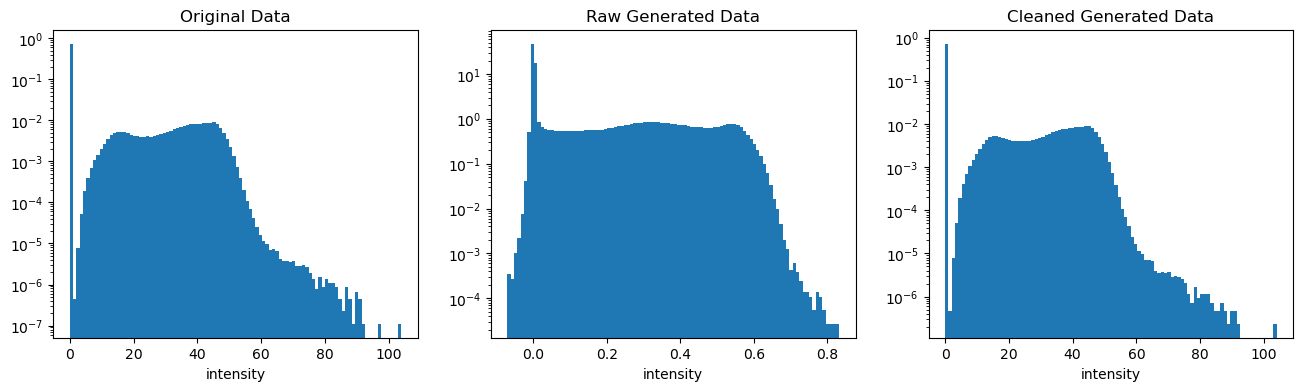

interactive(children=(FloatSlider(value=0.0, description='z', max=1.0, step=0.01), Output()), _dom_classes=('w…

<function __main__.show_slice(z)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from scipy.ndimage import gaussian_filter
from skimage.exposure import match_histograms

img_gen = nib.load("uncond_gen/y0_0.nii.gz")
img = nib.load("atlas/T1/sub-001.nii.gz")

data = img.get_fdata()
data_gen = img_gen.get_fdata()

def clean_background(img, sigma=1.0, thr_ratio=0.05):
    img = img.astype(np.float32)

    # 平滑
    smoothed = gaussian_filter(img, sigma=sigma)

    # 阈值
    thr = smoothed.max() * thr_ratio
    smoothed[smoothed < thr] = 0

    return smoothed

data_gen_clean = clean_background(data_gen, sigma=0.5, thr_ratio=0.02)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.hist(data.flatten(), bins=100, log=True, density=True)
plt.xlabel("intensity")
plt.title("Original Data")

plt.subplot(1, 3, 2)
# plt.hist(data[data < np.percentile(data, 20)].flatten(), bins=100, density=True)
plt.hist(data_gen.flatten(), bins=100, log=True, density=True)
plt.xlabel("intensity")
plt.title("Raw Generated Data")

plt.subplot(1, 3, 3)
plt.hist(data_gen_clean.flatten(), bins=100, log=True, density=True)
plt.xlabel("intensity")
plt.title("Cleaned Generated Data")

def show_slice(z):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    slice = int(z * (data.shape[2] - 1))
    print(slice)
    plt.imshow(data[:, :, slice].T, cmap="gray", origin="lower")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    slice = int(z * (data_gen.shape[1] - 1))
    plt.imshow(data_gen[:, slice, :].T, cmap="gray", origin="lower")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(data_gen_clean[:, slice, :].T, cmap="gray", origin="lower")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# print(f"20th percentile:   {np.percentile(data, 20):.4f}")
interact(show_slice, z=(0, 1, 0.01))

In [ ]:
img_np = data_gen_clean.reshape(160, 160, 160)
z = img_np.shape[2] // 2

def show_slice(z):
    plt.figure(figsize=(10, 5))

    # image
    plt.subplot(1, 2, 1)
    plt.imshow(img_np[:, z, :].T, cmap="gray", origin="lower")
    plt.title("Image")
    plt.axis("off")

    # label
    plt.subplot(1, 2, 2)
    plt.imshow(label_np[:, z, :].T, cmap="gray", origin="lower")
    plt.title("Label")
    plt.axis("off")

    plt.show()

interact(show_slice, z=(0, img_np.shape[2]-1))

interactive(children=(IntSlider(value=79, description='z', max=159), Output()), _dom_classes=('widget-interact…

<function __main__.show_slice(z)>

In [ ]:
# %matplotlib inline

path = "atlas/T1/sub-008.nii.gz"
# path = "atlas/pathology_maps_segmentation/sub-004.nii.gz" 
# path = "uncond_gen/x0_0.nii.gz"
# path = "uncond_gen/y0_0.nii.gz"

img = nib.load(path).get_fdata()
nii = nib.load(path)
print(aff2axcodes(nii.affine))
print("Image shape:", img.shape)
# print("Unique values:", np.unique(img))
print("left-right intensity diff:",
      np.mean(img[:20, :, :]) - np.mean(img[-20:, :, :]))

# affine = np.array([[-1,0,0],[0,0,-1],[0,-1,0]])
# img = affine @ img

z = img.shape[2] // 2  # 中间切片索引
# slice_img = img[:, :, z]

def get_slice(slice):
    print("Original slice shape:", slice.shape)
    target_size = (230, 182)
    # target_size = (182, 230)
    # slice = resize(slice, target_size, order=1, preserve_range=True, anti_aliasing=True)
    # resize = Resize(spatial_size=target_size, mode="bilinear")
    slice = cv2.resize(
    slice,
    target_size,  # (W, H)
    interpolation=cv2.INTER_LINEAR
    )
    print("Resized slice shape:", slice.shape)
    h, w = slice.shape
    max_side = max(h, w)
    pad_top = (max_side - h) // 2
    pad_bottom = max_side - h - pad_top
    pad_left = (max_side - w) // 2
    pad_right = max_side - w - pad_left

    slice = np.pad(slice, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=0)

    return slice

def show_slice(z):
    # clear_output(wait=True)
    # print("current z =", z)
    # slice = get_slice((img[z, :, :]))
    slice = (img[:, :, z])
    plt.figure(figsize=(6,6))
    plt.imshow((slice), cmap="gray")
    plt.title(f"Binary mid-slice z={z}")
    # plt.axis("off")
    plt.show()

# show_slice(z)

interact(show_slice, z=(0, img.shape[2] - 1, 1))

('R', 'A', 'S')
Image shape: (197, 233, 189)
left-right intensity diff: 0.0


interactive(children=(IntSlider(value=94, description='z', max=188), Output()), _dom_classes=('widget-interact…

<function __main__.show_slice(z)>

# Dataset statistics

In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
from nibabel.orientations import aff2axcodes

def get_foreground_center(img, threshold=None):
    img = np.asarray(img)

    if threshold is None:
        # 简单前景阈值：去掉背景 0
        mask = img != 0
    else:
        mask = img > threshold

    coords = np.argwhere(mask)
    if len(coords) == 0:
        return None
    return coords.mean(axis=0)

def summarize_nii(path):
    nii = nib.load(path)
    img = nii.get_fdata()

    orientation = aff2axcodes(nii.affine)
    shape = img.shape
    spacing = nii.header.get_zooms()[:3]
    center = get_foreground_center(img)

    return {
        "file": os.path.basename(path),
        "orientation": orientation,
        "shape": shape,
        "spacing": spacing,
        "center_voxel": None if center is None else tuple(np.round(center, 2)),
        "affine": nii.affine
    }

# files = sorted(glob.glob("uncond_gen/y_*.nii.gz", recursive=True))
files = sorted(glob.glob("atlas/T1/*.nii.gz", recursive=True))

results = []
for f in files:
    try:
        info = summarize_nii(f)
        results.append(info)
        print(f"{info['file']}")
        print("  orientation:", info["orientation"])
        print("  shape      :", info["shape"])
        print("  spacing    :", info["spacing"])
        print("  center     :", info["center_voxel"])
        print()
    except Exception as e:
        print(f"Failed: {f} -> {e}")

sub-001.nii.gz
  orientation: ('R', 'A', 'S')
  shape      : (197, 233, 189)
  spacing    : (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  center     : (np.float64(98.1), np.float64(111.9), np.float64(81.25))

sub-002.nii.gz
  orientation: ('R', 'A', 'S')
  shape      : (197, 233, 189)
  spacing    : (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  center     : (np.float64(98.5), np.float64(114.45), np.float64(81.93))

sub-003.nii.gz
  orientation: ('R', 'A', 'S')
  shape      : (197, 233, 189)
  spacing    : (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  center     : (np.float64(97.68), np.float64(111.92), np.float64(80.28))

sub-004.nii.gz
  orientation: ('R', 'A', 'S')
  shape      : (197, 233, 189)
  spacing    : (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  center     : (np.float64(97.62), np.float64(112.06), np.float64(80.8))

sub-005.nii.gz
  orientation: ('R', 'A', 'S')
  shape      : (197, 233, 189)
  spacing    : (np.float32(1.0), np.float32(1.0), n

KeyboardInterrupt: 

In [ ]:


def compute_image_mean_var(img_path, nonzero_only=True):
    arr = nib.load(img_path).get_fdata(dtype=np.float32)
    # vox = arr[arr != 0] if nonzero_only else arr.reshape(-1)
    vox = arr

    if vox.size == 0:
        return np.nan, np.nan, 0

    mean_val = float(np.mean(vox))
    var_val = float(np.var(vox))  # population variance
    return mean_val, var_val, int(vox.size)

def describe_array(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {
            "count": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "5%": np.nan,
            "25%": np.nan,
            "50%": np.nan,
            "75%": np.nan,
            "95%": np.nan,
            "max": np.nan,
        }

    return {
        "count": int(x.size),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "min": float(np.min(x)),
        "5%": float(np.percentile(x, 5)),
        "25%": float(np.percentile(x, 25)),
        "50%": float(np.percentile(x, 50)),
        "75%": float(np.percentile(x, 75)),
        "95%": float(np.percentile(x, 95)),
        "max": float(np.max(x)),
    }

def stats_on_train_data_np(train_data, image_key="image", nonzero_only=True):
    means, vars_, stds, n_vox = [], [], [], []
    per_image = []  # list of dict, 每张图结果

    for i, item in tqdm(enumerate(train_data), total=len(train_data)):
        img_path = item[image_key]
        m, v, n = compute_image_mean_var(img_path, nonzero_only=nonzero_only)
        s = float(np.sqrt(v)) if np.isfinite(v) else np.nan

        per_image.append({
            "idx": i,
            "image": img_path,
            "mean": m,
            "var": v,
            "std": s,
            "n_vox": n,
        })

        means.append(m)
        vars_.append(v)
        stds.append(s)
        n_vox.append(n)

    means = np.asarray(means, dtype=np.float64)
    vars_ = np.asarray(vars_, dtype=np.float64)
    n_vox = np.asarray(n_vox, dtype=np.float64)

    valid = np.isfinite(means) & np.isfinite(vars_) & (n_vox > 0)

    means_valid = means[valid]
    vars_valid = vars_[valid]
    w = n_vox[valid]

    mean_dist = describe_array(means_valid)
    var_dist = describe_array(vars_valid)

    # 整体统计口径1：每张图同权重
    if means_valid.size > 0:
        overall_mean_unweighted = float(np.mean(means_valid))
        overall_var_unweighted = float(np.mean(vars_valid))
    else:
        overall_mean_unweighted = np.nan
        overall_var_unweighted = np.nan

    overall_std_unweighted = float(np.sqrt(overall_var_unweighted)) if np.isfinite(overall_var_unweighted) else np.nan

    # 整体统计口径2：按体素加权
    if means_valid.size > 0:
        overall_mean_weighted = float(np.average(means_valid, weights=w))
        ex2_weighted = float(np.average(vars_valid + means_valid**2, weights=w))
        overall_var_weighted = float(ex2_weighted - overall_mean_weighted**2)
        overall_std_weighted = float(np.sqrt(max(overall_var_weighted, 0.0)))
    else:
        overall_mean_weighted = np.nan
        overall_var_weighted = np.nan
        overall_std_weighted = np.nan

    return {
        "per_image": per_image,
        "mean_distribution": mean_dist,
        "var_distribution": var_dist,
        "overall_unweighted": {
            "mean": overall_mean_unweighted,
            "var": overall_var_unweighted,
            "std": overall_std_unweighted,
        },
        "overall_weighted": {
            "mean": overall_mean_weighted,
            "var": overall_var_weighted,
            "std": overall_std_weighted,
        },
        "means_array": means_valid,
        "vars_array": vars_valid,
    }


  0%|          | 0/524 [00:00<?, ?it/s]

100%|██████████| 524/524 [00:49<00:00, 10.59it/s]


=== 每张图统计（前5个） ===
{'idx': 0, 'image': 'atlas/T1/sub-131.nii.gz', 'mean': 7.134909152984619, 'var': 174.4451141357422, 'std': 13.207767189640427, 'n_vox': 8675289}
{'idx': 1, 'image': 'atlas/T1/sub-325.nii.gz', 'mean': 6.434632778167725, 'var': 161.5591278076172, 'std': 12.71059116672459, 'n_vox': 8675289}
{'idx': 2, 'image': 'atlas/T1/sub-351.nii.gz', 'mean': 7.902039051055908, 'var': 243.93917846679688, 'std': 15.618552380640047, 'n_vox': 8675289}
{'idx': 3, 'image': 'atlas/T1/sub-129.nii.gz', 'mean': 11.744341850280762, 'var': 458.3708190917969, 'std': 21.409596425243443, 'n_vox': 8675289}
{'idx': 4, 'image': 'atlas/T1/sub-262.nii.gz', 'mean': 8.03439998626709, 'var': 225.6369171142578, 'std': 15.021215567132302, 'n_vox': 8675289}

=== train_data 中 mean 的分布 ===
 count: 524
  mean: 8.195853196482622
   std: 2.0432538590662723
   min: 3.4713094234466553
    5%: 5.247374629974365
   25%: 6.734371662139893
   50%: 8.05548620223999
   75%: 9.328230857849121
   95%: 11.98922410011291
   m

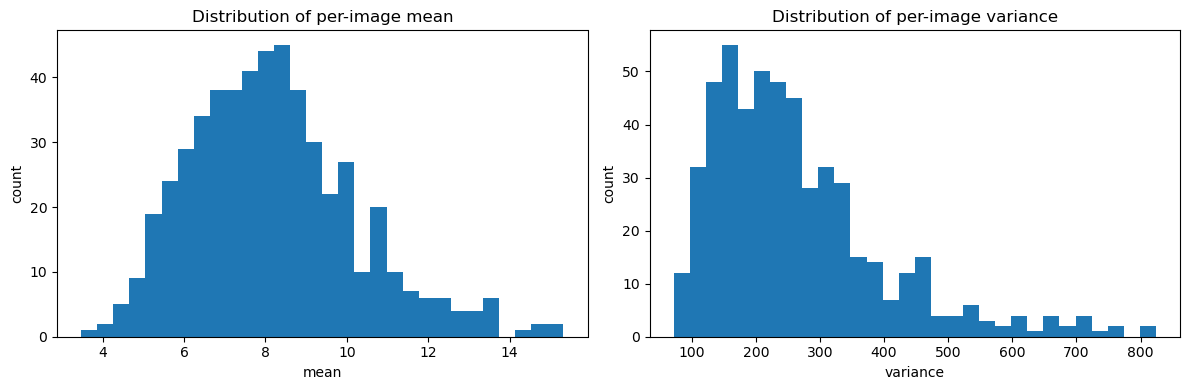

In [ ]:
# ===== 运行 =====
# 确保先执行：train_data, val_data = builder.build()
out = stats_on_train_data_np(train_data, image_key="image", nonzero_only=True)

print("=== 每张图统计（前5个） ===")
for row in out["per_image"][:5]:
    print(row)

print("\n=== train_data 中 mean 的分布 ===")
for k, v in out["mean_distribution"].items():
    print(f"{k:>6}: {v}")

print("\n=== train_data 中 var 的分布 ===")
for k, v in out["var_distribution"].items():
    print(f"{k:>6}: {v}")

print("\n=== train_data 整体统计（每图同权重） ===")
print(out["overall_unweighted"])

print("\n=== train_data 整体统计（按体素加权） ===")
print(out["overall_weighted"])

# 可视化分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(out["means_array"], bins=30)
axes[0].set_title("Distribution of per-image mean")
axes[0].set_xlabel("mean")
axes[0].set_ylabel("count")

axes[1].hist(out["vars_array"], bins=30)
axes[1].set_title("Distribution of per-image variance")
axes[1].set_xlabel("variance")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

100%|██████████| 131/131 [00:11<00:00, 11.05it/s]


=== 每张图统计（前5个） ===
{'idx': 0, 'image': 'atlas/T1/sub-033.nii.gz', 'mean': 10.616390228271484, 'var': 401.36761474609375, 'std': 20.034161193973002, 'n_vox': 8675289}
{'idx': 1, 'image': 'atlas/T1/sub-314.nii.gz', 'mean': 7.519253253936768, 'var': 188.82177734375, 'std': 13.74124366073719, 'n_vox': 8675289}
{'idx': 2, 'image': 'atlas/T1/sub-246.nii.gz', 'mean': 7.381402969360352, 'var': 189.30410766601562, 'std': 13.758782928224997, 'n_vox': 8675289}
{'idx': 3, 'image': 'atlas/T1/sub-192.nii.gz', 'mean': 7.706778049468994, 'var': 200.2568359375, 'std': 14.151213231998874, 'n_vox': 8675289}
{'idx': 4, 'image': 'atlas/T1/sub-018.nii.gz', 'mean': 8.436637878417969, 'var': 258.2591857910156, 'std': 16.070444480194553, 'n_vox': 8675289}

=== val_data 中 mean 的分布 ===
 count: 131
  mean: 8.387755190143148
   std: 2.2938455184639515
   min: 3.4646430015563965
    5%: 5.080731391906738
   25%: 6.844027042388916
   50%: 8.082599639892578
   75%: 9.479082107543945
   95%: 13.226426601409912
   max:

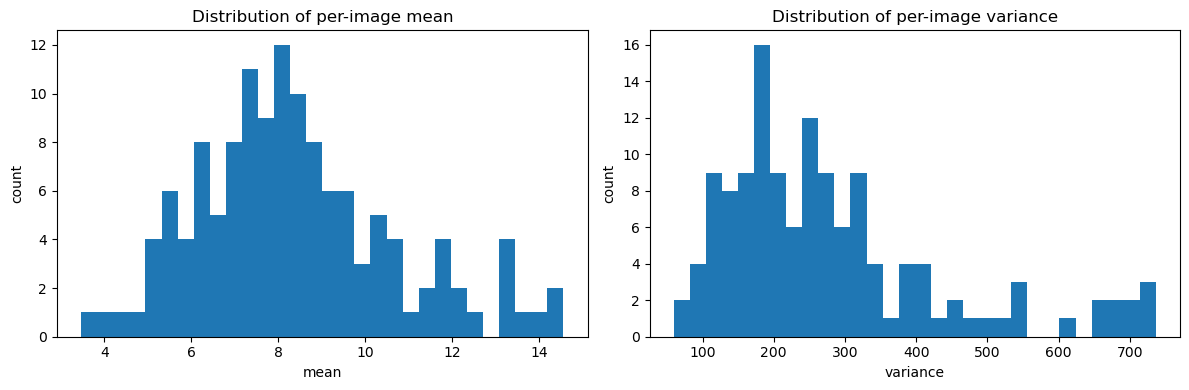

In [ ]:
# ===== 运行 =====
# 确保先执行：train_data, val_data = builder.build()
out = stats_on_train_data_np(val_data, image_key="image", nonzero_only=True)

print("=== 每张图统计（前5个） ===")
for row in out["per_image"][:5]:
    print(row)

print("\n=== val_data 中 mean 的分布 ===")
for k, v in out["mean_distribution"].items():
    print(f"{k:>6}: {v}")

print("\n=== val_data 中 var 的分布 ===")
for k, v in out["var_distribution"].items():
    print(f"{k:>6}: {v}")

print("\n=== val_data 整体统计（每图同权重） ===")
print(out["overall_unweighted"])

print("\n=== val_data 整体统计（按体素加权） ===")
print(out["overall_weighted"])

# 可视化分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(out["means_array"], bins=30)
axes[0].set_title("Distribution of per-image mean")
axes[0].set_xlabel("mean")
axes[0].set_ylabel("count")

axes[1].hist(out["vars_array"], bins=30)
axes[1].set_title("Distribution of per-image variance")
axes[1].set_xlabel("variance")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:10<00:00,  9.52it/s]


=== 每张图统计（前5个） ===
{'idx': 0, 'image': 'uncond_gen/y0_432.nii.gz', 'mean': 0.0868726298213005, 'var': 0.015651321038603783, 'std': 0.12510523985270874, 'n_vox': 4096000}
{'idx': 1, 'image': 'uncond_gen/y0_215.nii.gz', 'mean': 0.19690196216106415, 'var': 0.06704352051019669, 'std': 0.25892763566331944, 'n_vox': 4096000}
{'idx': 2, 'image': 'uncond_gen/y0_366.nii.gz', 'mean': 0.11872918158769608, 'var': 0.029644541442394257, 'std': 0.17217590261820687, 'n_vox': 4096000}
{'idx': 3, 'image': 'uncond_gen/y0_326.nii.gz', 'mean': 0.22037842869758606, 'var': 0.08707679808139801, 'std': 0.2950877802983343, 'n_vox': 4096000}
{'idx': 4, 'image': 'uncond_gen/y0_47.nii.gz', 'mean': 0.1248784288764, 'var': 0.027673430740833282, 'std': 0.16635333101814728, 'n_vox': 4096000}

=== gen_data 中 mean 的分布 ===
 count: 100
  mean: 0.14350987680256366
   std: 0.0475416359102479
   min: 0.06307394802570343
    5%: 0.07526442408561707
   25%: 0.104726767167449
   50%: 0.14652404934167862
   75%: 0.17825206369161

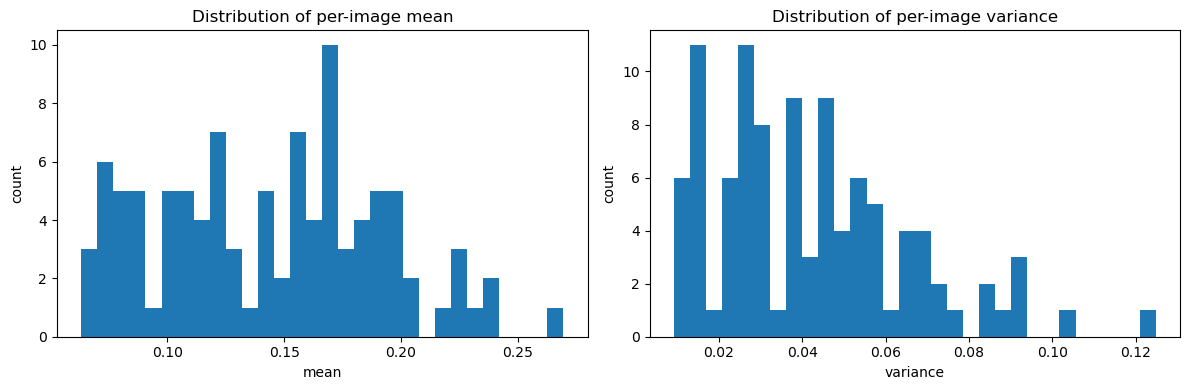

In [ ]:
# ===== 运行 =====
# 确保先执行：train_data, val_data = builder.build()
out = stats_on_train_data_np(gen_data, image_key="image", nonzero_only=True)

print("=== 每张图统计（前5个） ===")
for row in out["per_image"][:5]:
    print(row)

print("\n=== gen_data 中 mean 的分布 ===")
for k, v in out["mean_distribution"].items():
    print(f"{k:>6}: {v}")

print("\n=== gen_data 中 var 的分布 ===")
for k, v in out["var_distribution"].items():
    print(f"{k:>6}: {v}")

print("\n=== gen_data 整体统计（每图同权重） ===")
print(out["overall_unweighted"])

print("\n=== gen_data 整体统计（按体素加权） ===")
print(out["overall_weighted"])

# 可视化分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(out["means_array"], bins=30)
axes[0].set_title("Distribution of per-image mean")
axes[0].set_xlabel("mean")
axes[0].set_ylabel("count")

axes[1].hist(out["vars_array"], bins=30)
axes[1].set_title("Distribution of per-image variance")
axes[1].set_xlabel("variance")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()